In [1]:
from models.analyzer import FeatureSelectionAnalyzer

In [2]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

In [3]:
data = pd.read_excel("./data_raw/DataSet_V49 (2).xlsx")

In [4]:
data.dropna(subset=['Смерть'], inplace=True)
data['Смерть'] = data['Смерть'].map({'Да': 1, 'Нет': 0})

In [5]:
cols = [
    "Смерть",
    "Age",
    "Sex",
    "Рост",
    "Вес",
    "Индекс массы тела", 
    "Инфаркт миокарда в анамнезе (<3)",
    "Инфаркт миокарда в анамнезе (>3)",
    "Инфаркт миокарда со стентированием в анамнезе",
    "ОНМК (иш) в анамнезе",
    "ОНМК (гем) в анамнезе",
    "Стентирование в анамнезе",
    "Открытая перация на сердце в анамнезе",
    "ГБ стадия",
    "ГБ риск",
    "АГ",
    "СД",
    "ХБП",
    "ЯБ",
    "МКБ",
    "ЖКБ",
    "ХОБЛ (Новый столбец)",
    "Курит",
    "Экстракардиальная артериопатия",
    "Плохая мобильность",
    "Стенокардия (ИБ)",
    "Стенокардия форма(ИБ)",
    "Стенокардия ФК (ИБ)",
    "Стенокардия в диагнозе при поступлении",
    "ПИКС в диагнозе при поступлении",
    "Форма ФП",
    "ФП постоянная форма",
    "ФП при окс (до чкв)", 
    "ЧКВ",
    "Инфаркт-зависимая артерия",
    "Поражение ствола",
    "Количество пораженных сосудов(Syntax)",
    "Количество пораженных сосудов(Значимость)",
    "TIMI",
    "Класс ОСН по Killip",
    "ХСН стадия",
    "ФЖ",
    "Пробежки ЖТ",
    "Рецидивирующая ЖТ",
    "Срочность",
    "Экстренная операция(ИБ)(Новый)",
    "Вид операции(ИБ)(Новый)",
    "Тромболизис",
    "Медицинская помощь оказана за первые 4 часа",
    "Гипертоническая болезнь",
    "ФВ < 40",
    "А-В блокада",
    "А-В блокада (степень)",
]

In [5]:
category_cols = [
    "Sex", "STEMI", "ЧКВ", "Вид STEMI", "Инфаркт-зависимая артерия",
    "Поражение ствола","Инфаркт миокарда в анамнезе (<3)",
    "Инфаркт миокарда в анамнезе (>3)",'Инфаркт миокарда со стентированием в анамнезе',
    'ОНМК (иш) в анамнезе', 'ОНМК (гем) в анамнезе','Стентирование в анамнезе',
    'Тромболизис', 'Форма ФП', 'Калий', 'Дилатация предсердий','ФП b (после чкв)',
    'ФП a (в анамнезе)', 'ФП при окс (до чкв)', 'ФП постоянная форма', 'ФЖ',
    'Пробежки ЖТ', 'Рецидивирующая ЖТ', 'MKB', 'Класс ОСН по Killip',
    'ХСН стадия', 'АГ', 'Стенокардия (ИБ)', 'Стенокардия форма(ИБ)',
    'Стенокардия ФК (ИБ)', 'СД', 'ХБП', 'ЯБ', 'МКБ', 'ЖКБ', 'Стеноз аортального клапана (степень)',
    'Недостаточность трикуспидального клапана (степень)', 'НПВ', 'Экстренная операция(ИБ)(Новый)',
    'Вид операции(ИБ)(Новый)', 'повторные операции','Тип первой операции БД',
    'Тип повторной операции', 'GRACE(Общее)>140', 'интегрилин|эптифибатид|коромакс|агграстат',
    'Экстракардиальная артериопатия', 'Плохая мобильность', 'Открытая перация на сердце в анамнезе',
    'Срочность', 'Сопутствующие1', 'Сопутствующие2', 'Тропонин 1 > 0.1 (b)', 'Тропонин 1 > 0.1 (a)',
    'Тропонин 1 > 0.1', 'Smoking', 'Протокол коронарографии', 'Аортальный стеноз (Градиент)',
    'Аортальный стеноз (Заключение)', 'ХОБЛ (Новый столбец)', 'Коррекция А-В блокады',
    'Исход А-В блокады', 'Начало А-В блокады (До/после ЧКВ)', 'А-В блокада',
    'Стенокардия в диагнозе при поступлении', 'ПИКС в диагнозе при поступлении',
    'Инфаркт-зависимая артерия(Огригированная)', 'Инфаркт-зависимая артерия(Огригированная)2',
    'Ишемический инсульт (Выгрузка из ИБ - временный столбец)', 'Геморрагический инсульт (Выгрузка из ИБ - временный столбец)',
    'Инсульт (Выгрузка из ИБ - временный столбец)', 'Курит', 'GRACE(Общее)>156', 'Отек легких(b)',
    'Отек легких(a)', 'Отек легких', 'Медицинская помощь оказана за первые 4 часа',
    'Гипертоническая болезнь', 'ФВ < 40', 'CADILLAC (Низкий риск)', 'CADILLAC (Средний риск)',
    'CADILLAC (Высокий риск)', 'РЕКОРД (Низкий риск)', 'РЕКОРД (Высокий риск)',
    'GRACE (Низкий риск)', 'GRACE (Средний риск)', 'GRACE (Высокий риск)',
    'TIMI (Летальность) (Низкий риск)', 'TIMI (Летальность) (Средний риск)',
    'TIMI (Летальность) (Высокий риск)', 'PAMI (Низкий риск)', 'PAMI (Средний риск)',
    'PAMI (Высокий риск)', 'А-В блокаДа (Новый)', 'А-В блокада (степень)',
    'Используемый антибиотик ДО развития SOFA 8 и более',
    'Левофлоксацин антибиотик ДО развития SOFA 8 и более',
    'Линезолид антибиотик ДО развития SOFA 8 и более',
    'Меропенем антибиотик ДО развития SOFA 8 и более',
    'Метронидазол антибиотик ДО развития SOFA 8 и более',
    'Моксифлоксацин антибиотик ДО развития SOFA 8 и более',
    'Нифуроксазид антибиотик ДО развития SOFA 8 и более',
    'Фосфомицин антибиотик ДО развития SOFA 8 и более',
    'Цефазолин антибиотик ДО развития SOFA 8 и более',
    'Сульбактам антибиотик ДО развития SOFA 8 и более',
    'Цефоперазон антибиотик ДО развития SOFA 8 и более',
    'Цефтриаксон антибиотик ДО развития SOFA 8 и более',
    'Антибиотик после развития SOFA 8 и более',
    'Моксифлоксацин после развития SOFA 8 и более',
    'Левофлоксацин после развития SOFA 8 и более',
    'Азитромицин после развития SOFA 8 и более',
    'Линезолид после развития SOFA 8 и более',
    'Меропенем после развития SOFA 8 и более',
    'Метронидазол после развития SOFA 8 и более',
    'Нифуроксазид после развития SOFA 8 и более',
    'Фосфомицин после развития SOFA 8 и более',
    'Цефазолин после развития SOFA 8 и более',
    'Сульбактам после развития SOFA 8 и более',
    'Цефепим после развития SOFA 8 и более',
    'Цефтриаксон после развития SOFA 8 и более',
    'ИВЛ', 'Вазопрессорная поддержка', 'Адреналин',
    'Добутамин', 'Допмин', 'Норадреналин', 'Левосимендан',
    'Мезатон', 'UA (нестабильная стенокардия)','Синдромный диагноз','Смерть'
]

In [7]:
cols_to_delete = [
    "Код пациента", "Name", "Дата STEMI", "Дата направления (Общий анализ крови)", 
    "Дата взятия биоматериала (Общий анализ крови)", "Дата выполнения (Общий анализ крови)", 
    "Дата направления (Общий анализ крови-экспрес)", "Дата взятия биоматериала (Общий анализ крови-экспрес)",
    "Дата выполнения (Общий анализ крови-экспрес)", "Начало операции(ИБ)(Новый)", "Конец операции(ИБ)(Новый)", 
    "дата поступления", "дата выписки", "дата смерти", "Исход заболевания", "Поступление в реанимацию", 
    "Выписка из реанимации", "Файл(Анализы)", "Файл(ИБ)","Наличие в БД", "Наличие в файле", "Bypass#", 
    "Повторная оперция", "Смерть в реанимации", "Причина смерти", "Осложнения", "SmokeIndex", "Ход операции", 
    "Общий анализ крови раньше операции", "Общий анализ крови_экспресс раньше операции", "Отделение", 
    "Запись требует проверки", "Индекс курения", "Летальный исход икка", "Диагноз", 
    "Дата и время развития SOFA 8 и более", "Время введения первого антибиотика", 
    "Набор данных (Данные Кокарев)", "Unnamed: 344", "В базе данных", 
    "SYNTAX Score", "ХСН фк", "КДР ЛЖ", "КСР ЛЖ", "ДАД(a)", "Кардиогенный шок",
    'длительность нахождения в стационаре',
    'GRACE(Общее)>140',
    'GRACE(Общее)>156',
    'Отек легких(b)',
    'Отек легких(a)', 'Отек легких',
    'CADILLAC (Низкий риск)', 'CADILLAC (Средний риск)',
    'CADILLAC (Высокий риск)', 'РЕКОРД (Низкий риск)', 'РЕКОРД (Высокий риск)',
    'GRACE (Низкий риск)', 'GRACE (Средний риск)', 'GRACE (Высокий риск)',
    'TIMI (Летальность) (Низкий риск)', 'TIMI (Летальность) (Средний риск)',
    'TIMI (Летальность) (Высокий риск)', 'PAMI (Низкий риск)', 'PAMI (Средний риск)',
    'PAMI (Высокий риск)',
    'МКБ', 'ЖКБ',
    'Протокол коронарографии',
    'Класс ОСН по Killip',
    'ФВ < 40',
    "Мочевина(a)",
    'Используемый антибиотик ДО развития SOFA 8 и более',
    'Левофлоксацин антибиотик ДО развития SOFA 8 и более',
    'Линезолид антибиотик ДО развития SOFA 8 и более',
    'Меропенем антибиотик ДО развития SOFA 8 и более',
    'Метронидазол антибиотик ДО развития SOFA 8 и более',
    'Моксифлоксацин антибиотик ДО развития SOFA 8 и более',
    'Нифуроксазид антибиотик ДО развития SOFA 8 и более',
    'Фосфомицин антибиотик ДО развития SOFA 8 и более',
    'Цефазолин антибиотик ДО развития SOFA 8 и более',
    'Сульбактам антибиотик ДО развития SOFA 8 и более',
    'Цефоперазон антибиотик ДО развития SOFA 8 и более',
    'Цефтриаксон антибиотик ДО развития SOFA 8 и более',
    'Антибиотик после развития SOFA 8 и более',
    'Моксифлоксацин после развития SOFA 8 и более',
    'Левофлоксацин после развития SOFA 8 и более',
    'Азитромицин после развития SOFA 8 и более',
    'Линезолид после развития SOFA 8 и более',
    'Меропенем после развития SOFA 8 и более',
    'Метронидазол после развития SOFA 8 и более',
    'Нифуроксазид после развития SOFA 8 и более',
    'Фосфомицин после развития SOFA 8 и более',
    'Цефазолин после развития SOFA 8 и более',
    'Сульбактам после развития SOFA 8 и более',
    'Цефепим после развития SOFA 8 и более',
    'Цефтриаксон после развития SOFA 8 и более',
    "TIMI",
    "GRACE(Общее)",
    "GRACE(Общее)>140",
    "GRACE(Общее)>156",
    "TIMI (Летальность)",
    "GRACE (Низкий риск)",
    "GRACE (Средний риск)",
    "GRACE (Высокий риск)",
    "TIMI (Летальность) (Низкий риск)",
    "TIMI (Летальность) (Средний риск)",
    "TIMI (Летальность) (Высокий риск)",
    "Дата и время развития SOFA 8 и более",
    "Часов в ОРИТ ДО развития SOFA 8",
    "Часов в ОРИТ ПОСЛЕ развития SOFA 8",
    "Максимальный прокальцитонин за сутки до развития SOFA 8",
    "Максимальный ЛАКТАТ артерия за сутки до развития SOFA 8",
    "Максимальный ЛАКТАТ вена за сутки до развития SOFA 8",
    "Максимальный ЛАКТАТ артерия за сутки после развития SOFA 8",
    "Максимальный ЛАКТАТ вена за сутки после развития SOFA 8",
    "SOFA первый раз больше или равна 8 баллам",
    "SOFA до развития 8 и более баллов",
    "Используемый антибиотик ДО развития SOFA 8 и более",
    "Левофлоксацин антибиотик ДО развития SOFA 8 и более",
    "Линезолид антибиотик ДО развития SOFA 8 и более",
    "Меропенем антибиотик ДО развития SOFA 8 и более",
    "Метронидазол антибиотик ДО развития SOFA 8 и более",
    "Моксифлоксацин антибиотик ДО развития SOFA 8 и более",
    "Нифуроксазид антибиотик ДО развития SOFA 8 и более",
    "Фосфомицин антибиотик ДО развития SOFA 8 и более",
    "Цефазолин антибиотик ДО развития SOFA 8 и более",
    "Сульбактам антибиотик ДО развития SOFA 8 и более",
    "Цефоперазон антибиотик ДО развития SOFA 8 и более",
    "Цефтриаксон антибиотик ДО развития SOFA 8 и более",
    "Количество часов применения антибиотика ДО развития SOFA 8 и более",
    "Антибиотик после развития SOFA 8 и более",
    "Моксифлоксацин после развития SOFA 8 и более",
    "Левофлоксацин после развития SOFA 8 и более",
    "Азитромицин после развития SOFA 8 и более",
    "Линезолид после развития SOFA 8 и более",
    "Меропенем после развития SOFA 8 и более",
    "Метронидазол после развития SOFA 8 и более",
    "Нифуроксазид после развития SOFA 8 и более",
    "Фосфомицин после развития SOFA 8 и более",
    "Цефазолин после развития SOFA 8 и более",
    "Сульбактам после развития SOFA 8 и более",
    "Цефепим после развития SOFA 8 и более",
    "Цефтриаксон после развития SOFA 8 и более",
    "Через сколько часов после развития SOFA 8 и более был введен антибиотик",
    "APACHE сутки до развития SOFA 8 и более",
    "APACHE сутки ПОСЛЕ развития SOFA 8 и более",
    "АД среднее за сутки до развития SOFA 8",
    "Среднее АД 1 сутки в орит",
    "Среднее АД 3 сутки в орит",
    "Среднее АД 7 сутки в орит",
    "Среднее ЧСС 1 сутки",
    "Среднее ЧСС 3 сутки",
    "Среднее ЧСС 7 сутки",
    "Экстренная операция(ИБ)(Новый)",
    "ИВЛ",
    "Количество дней в реанимации",
    "Часов до введения первого антибиотика",
    "Часов в ОРИТ ДО развития SOFA 8",
    "Apache II",
    "TIMI Летальность",
    "Количество пораженных сосудов Syntax", 
    "Поражение ствола", 
    "Инфаркт-зависимая артерия",
    "Вазопрессорная поддержка",
    "Адреналин",
    "Добутамин",
    "Норадреналин",
    "Левосимендан",
    "Макс АД 1 сут",
    "Мин ЧСС 7 сутки",
    "Макс АД 7 сут",
    "CADILLAC",
    "PAMI",
    "РЕКОРД", 
    "Инфаркт-зависимая артерия Огригированная",
]

In [8]:
for col in cols_to_delete:
    try:
        data.drop([col], axis=1, inplace=True)
    except Exception as e: 
        print(col, e)

        for i in data.columns:
            if col in i:
                print("Found ", col, i)


GRACE(Общее)>140 "['GRACE(Общее)>140'] not found in axis"
GRACE(Общее)>156 "['GRACE(Общее)>156'] not found in axis"
GRACE (Низкий риск) "['GRACE (Низкий риск)'] not found in axis"
GRACE (Средний риск) "['GRACE (Средний риск)'] not found in axis"
GRACE (Высокий риск) "['GRACE (Высокий риск)'] not found in axis"
TIMI (Летальность) (Низкий риск) "['TIMI (Летальность) (Низкий риск)'] not found in axis"
TIMI (Летальность) (Средний риск) "['TIMI (Летальность) (Средний риск)'] not found in axis"
TIMI (Летальность) (Высокий риск) "['TIMI (Летальность) (Высокий риск)'] not found in axis"
Дата и время развития SOFA 8 и более "['Дата и время развития SOFA 8 и более'] not found in axis"
Используемый антибиотик ДО развития SOFA 8 и более "['Используемый антибиотик ДО развития SOFA 8 и более'] not found in axis"
Левофлоксацин антибиотик ДО развития SOFA 8 и более "['Левофлоксацин антибиотик ДО развития SOFA 8 и более'] not found in axis"
Линезолид антибиотик ДО развития SOFA 8 и более "['Линезолид а

In [38]:
data

,Age,Sex,STEMI,ЧКВ,Вид STEMI,Количество пораженных сосудов(Syntax),Количество пораженных сосудов(Значимость),Инфаркт миокарда в анамнезе (<3),Инфаркт миокарда в анамнезе (>3),Инфаркт миокарда со стентированием в анамнезе,ОНМК (иш) в анамнезе,ОНМК (гем) в анамнезе,Стентирование в анамнезе,Тромболизис,Форма ФП,Калий,Дилатация предсердий,ФП b (после чкв),ФП a (в анамнезе),ФП при окс (до чкв),ФП постоянная форма,ФЖ,Пробежки ЖТ,Рецидивирующая ЖТ,MKB,ХСН стадия,ГБ стадия,ГБ риск,АГ,Стенокардия (ИБ),Стенокардия форма(ИБ),Стенокардия ФК (ИБ),СД,ХБП,ЯБ,ФВ ЛЖ (b),ФВ ЛЖ,EDV,МЖП,ЗСЛЖ,ПСПЖ,СДЛА,Размер правого желудочка,Стеноз аортального клапана (степень),Недостаточность аортального клапана (степень),Стеноз митрального клапана (степень),Недостаточность митрального клапана (степень),Недостаточность трикуспидального клапана (степень),НПВ,НПВ диаметр,La1,La2,Ra1,Ra2,Гематокрит,Гемоглобин,Эритроциты,Лейкоциты,Тромбоциты,Нейтрофилы (абсолютное значение),Нейтрофилы (относительное значение),Лимфоциты (абсолютное значение),Лимфоциты (относительное значение),Моноциты (абсолютное значение),Моноциты (относительное значение),Эозинофилы (абсолютное значение),Эозинофилы (относительное значение),Базофилы (абсолютное значение),Базофилы (относительное значение),Сумма всех лейкоцитов,Средний объем эритроцита,Среднее содержание гемоглобина в эритроците,"Ср, концентрация гемоглобина в эритроците",Распределение эритроцитов по объему (RDW-CV),Распределение эритроцитов по объему (RDW-SD),Средний объем тромбоцита (MPV),Расчетная ширина распределения тромбоцитов,Тромбокрит,Коэффициент крупных тромбоцитов,СОЭ,С-реактивный белок,PLR (тромбоциты/лимфоциты абс) (61-239),MLR (моноциты/лимфоциты),LMR (лимфоциты абс/моноциты абс),SII (тромбоциты*нейтрофилы абс / лимфоциты абс),ELR (эозинофилы абс/лимфоциты абс,ELR %,ENR (эозин абс/нейтрофилы абс),BLR (базофилы абс/лимфоциты абс),SIRI (NxM)/L,PIV or AISI (NxMxPLT)/L,GLR (глюкоза мг/дл / лимф абс),FLR (fibr/L abs),RLR (RDW/ lymph abs),MPV/PC (MPV/ PLT),Глюкоза в мг/дл,Фибриноген,Эозинофилы(%)(b),Палочкоядерные нейтрофилы(%)(b),Cегментоядерные нейтрофилы(%)(b),Лимфоциты(%)(b),Моноциты(%)(b),Общий белок(b),Глюкоза(b),АСАТ(b),АЛАТ(b),Билирубин общий(b),Холестерин общий(b),Триглицериды(b),Креатинин(b),Мочевина(b),ЛДГ(b),КФК(b),КФК-МВ(b),ПТИ(b),МНО(b),ТВ(b),АПТВ(b),Продолжительность операции,Вид операции(ИБ)(Новый),Смерть,повторные операции,Тип первой операции БД,Тип повторной операции,интегрилин|эптифибатид|коромакс|агграстат,Рост,Вес,Индекс массы тела,Экстракардиальная артериопатия,Плохая мобильность,Открытая перация на сердце в анамнезе,Срочность,Систолическое АД(b),Диастолического АД(b),ЧСС (b),САД(a),ЧСС(а),P,PQ,QRS,QT,RR,Лейкоциты(a),Нейтрофилы (абсолютное значение)(a),Лимфоциты (абсолютное значение)(a),Моноциты (абсолютное значение)(a),Эозинофилы (абсолютное значение)(a),Базофилы (абсолютное значение)(a),Эр(a),Hb(a),Гематокрит(a),Тромбоциты(a),СОЭ(a),Эозинофилы(%)(a),Палочкоядерные нейтрофилы(%)(a),Cегментоядерные нейтрофилы(%)(a),Лимфоциты(%)(a),Моноциты(%)(a),Миелоциты(%)(a),Общий белок(a),Глюкоза(a),АСАТ(a),АЛАТ(a),Билирубин общий(a),Холестерин общий(a),Триглицериды(a),Креатинин(a),ЛДГ(a),КФК(a),КФК-МВ(a),ПТИ(a),МНО(a),ФБГ(a),ТВ(a),АПТВ(a),Сопутствующие1,Сопутствующие2,eGFR (a),Креатинин,СКФ,Тропонин 1 (b),Тропонин 1 > 0.1 (b),Тропонин 1 (a),Тропонин 1 > 0.1 (a),Тропонин 1,Тропонин 1 > 0.1,Smoking,Аортальный стеноз (Градиент),Аортальный стеноз (Заключение),ХОБЛ (Новый столбец),Коррекция А-В блокады,Исход А-В блокады,Начало А-В блокады (До/после ЧКВ),А-В блокада,Стенокардия в диагнозе при поступлении,ПИКС в диагнозе при поступлении,Инфаркт-зависимая артерия(Огригированная),Инфаркт-зависимая артерия(Огригированная)2,Ишемический инсульт (Выгрузка из ИБ - временный столбец),Геморрагический инсульт (Выгрузка из ИБ - временный столбец),Инсульт (Выгрузка из ИБ - временный столбец),SpO2,Курит,Медицинская помощь оказана за первые 4 часа,Гипертоническая болезнь,Время ЧКВ,А-В блокаДа (Новый),А-В блокада (степень),Минимальное АД 

In [9]:
for col in category_cols:
    if col not in cols_to_delete:
        data[col] = data[col].fillna('missing').astype('str')
        data[col] = data[col].astype('category')

In [10]:
X = data.drop(["Смерть"], axis=1)
y = data["Смерть"].astype('int')

In [11]:
def clean_column_names(df):
    """
    Очищает имена колонок от символов, которые не принимает XGBoost
    """
    new_columns = []
    for col in df.columns:
        # Удаляем запрещенные символы
        clean_col = col.replace('[', '_').replace(']', '_').replace('<', '_lt_')
        # Удаляем другие потенциально проблемные символы
        clean_col = clean_col.replace('>', '_gt_').replace(' ', '_').replace(':', '_')
        clean_col = clean_col.replace('(', '_').replace(')', '_').replace(',', '_')
        clean_col = clean_col.replace('{', '_').replace('}', '_').replace('|', '_')
        # Удаляем последовательные подчеркивания
        clean_col = '_'.join(filter(None, clean_col.split('_')))
        # Удаляем подчеркивания в начале и конце
        clean_col = clean_col.strip('_')
        # Если имя начинается с цифры, добавляем префикс
        if clean_col and clean_col[0].isdigit():
            clean_col = 'f_' + clean_col
        new_columns.append(clean_col)
    
    # Создаем копию DataFrame с новыми именами колонок
    df_clean = df.copy()
    df_clean.columns = new_columns
    return df_clean

# Применяем к вашим данным
X_clean = clean_column_names(X)

In [12]:
cat_features = []
for col in X_clean.columns:
    try:
        if X_clean[col].dtype.name == 'category': 
            cat_features.append(col)
    except Exception as e:
        print(col)

In [13]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [14]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm
import time

In [15]:
scale_pos_weight = len(y[y == 0]) / max(1, len(y[y == 1]))
class_weight_dict = {0: 1, 1: scale_pos_weight}

print(f"scale pos weight: {scale_pos_weight}")

scale pos weight: 27.89217391304348


In [16]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # борьба с дисбалансом
    missing=np.nan,  # явно указываем, что NaN - это пропуски
    random_state=42,
    eval_metric='logloss',  # для бинарной классификации
    tree_method='auto',  # автоматический выбор метода обучения
    enable_categorical=True
)

lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    class_weight=class_weight_dict,  # борьба с дисбалансом
    random_state=42,
    verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    # early_stopping_rounds=50  # задается при инициализации
)

cat_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    class_weights=[1, scale_pos_weight],  # борьба с дисбалансом
    random_state=42,
    verbose=False,
    eval_metric='Logloss',
    early_stopping_rounds=50,  # задается при инициализации
    # cat_features=list(X.select_dtypes(include=['category']).columns)
)

In [17]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(cat_model, max_features=None, metric='roc_auc')

=== FORWARD SELECTION ===
Запуск Forward Selection...


  0%|          | 1/326 [00:33<3:02:35, 33.71s/it, roc_auc=0.7994, Features=1]

Step 1: Добавлен признак 'Креатинин', roc_auc: 0.7994


  1%|          | 2/326 [01:11<3:16:25, 36.38s/it, roc_auc=0.8714, Features=2]

Step 2: Добавлен признак 'СДЛА', roc_auc: 0.8714


...

Step 14: Добавлен признак 'PLR_тромбоциты/лимфоциты_абс_61-239', roc_auc: 0.9705


  5%|▍         | 15/326 [12:38<4:52:13, 56.38s/it, roc_auc=0.9712, Features=15]

Step 15: Добавлен признак 'HCO3ArtMax_b', roc_auc: 0.9712


  5%|▍         | 15/326 [13:37<4:42:27, 54.49s/it, roc_auc=0.9712, Features=15]

Step 16: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 15


In [18]:
print("\n=== BACKWARD ELIMINATION ===")
backward_features = analyzer.backward_elimination(cat_model, min_features=1, metric='roc_auc')


=== BACKWARD ELIMINATION ===
Запуск Backward Elimination...


  0%|          | 1/325 [06:08<33:10:27, 368.60s/it, roc_auc=0.9637, Features=325]

Step 1: Удален признак 'Инфаркт_миокарда_в_анамнезе_lt_3', roc_auc: 0.9637


  0%|          | 1/325 [12:15<66:13:55, 735.91s/it, roc_auc=0.9637, Features=325]

Step 2: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 325



=== СРАВНЕНИЕ МЕТОДОВ ===


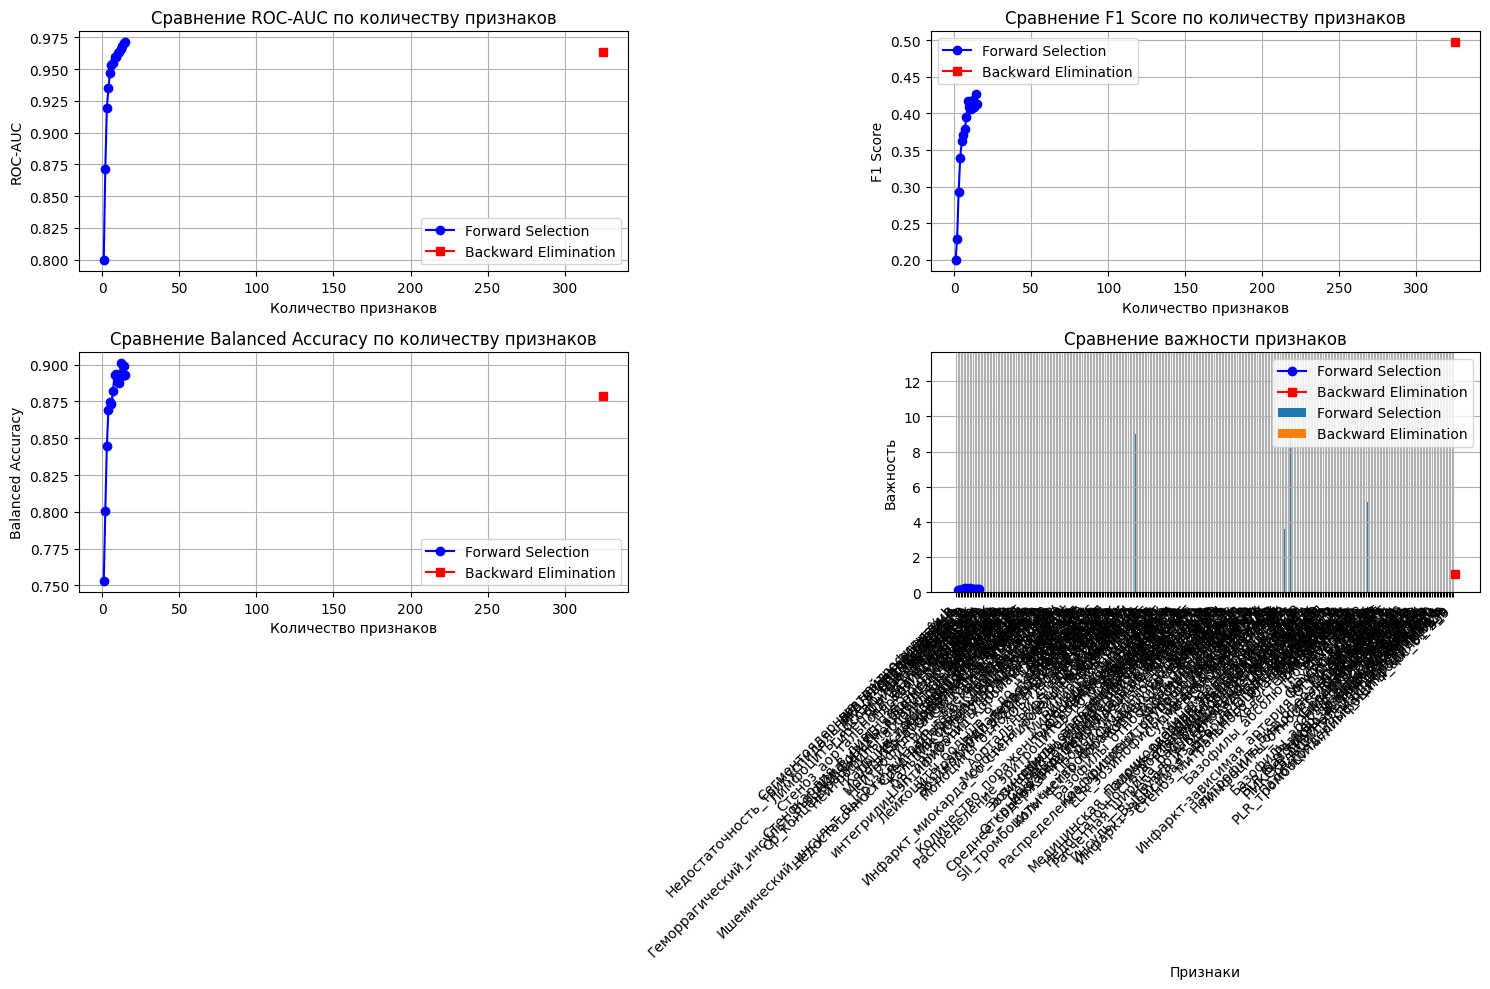

In [19]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [20]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 15 признаков) ===
По Balanced Accuracy score: 0.7900 (F1=0.6316)
По Youden's J: 0.3142


In [21]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 325 признаков) ===
По Balanced Accuracy score: 0.8500 (F1=0.6364)
По Youden's J: 0.3344



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


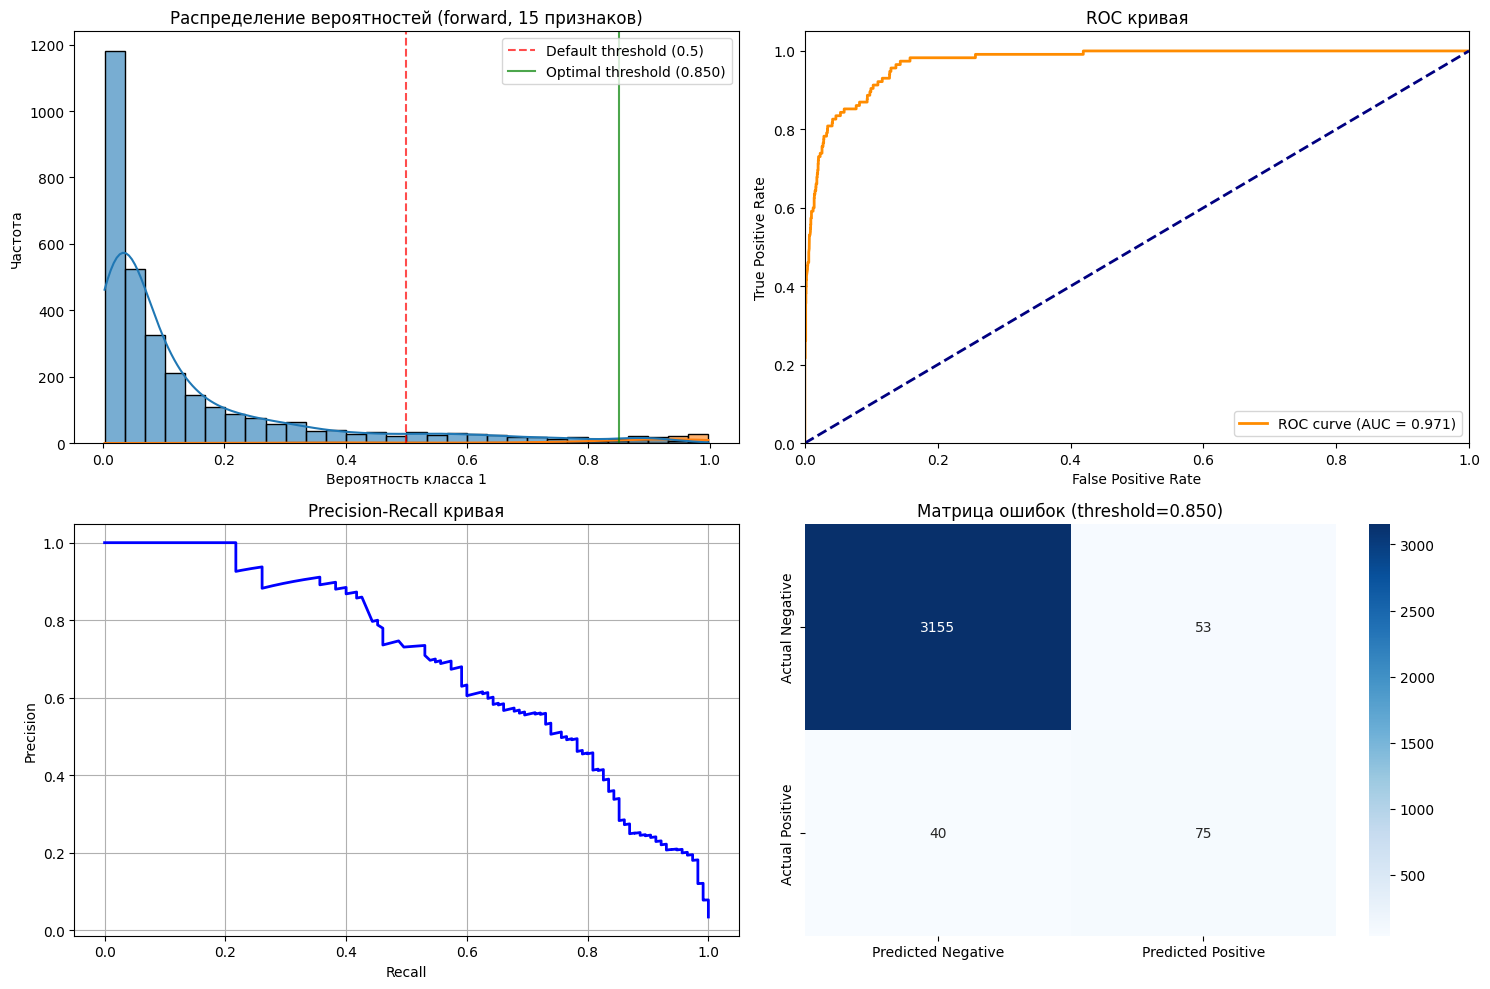

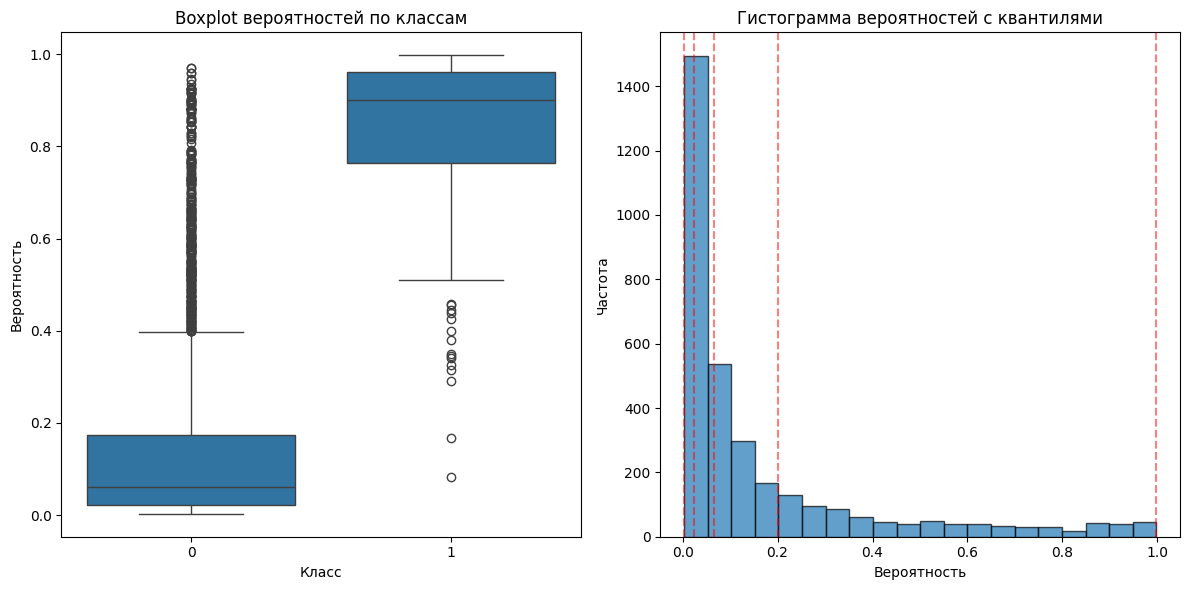

In [22]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


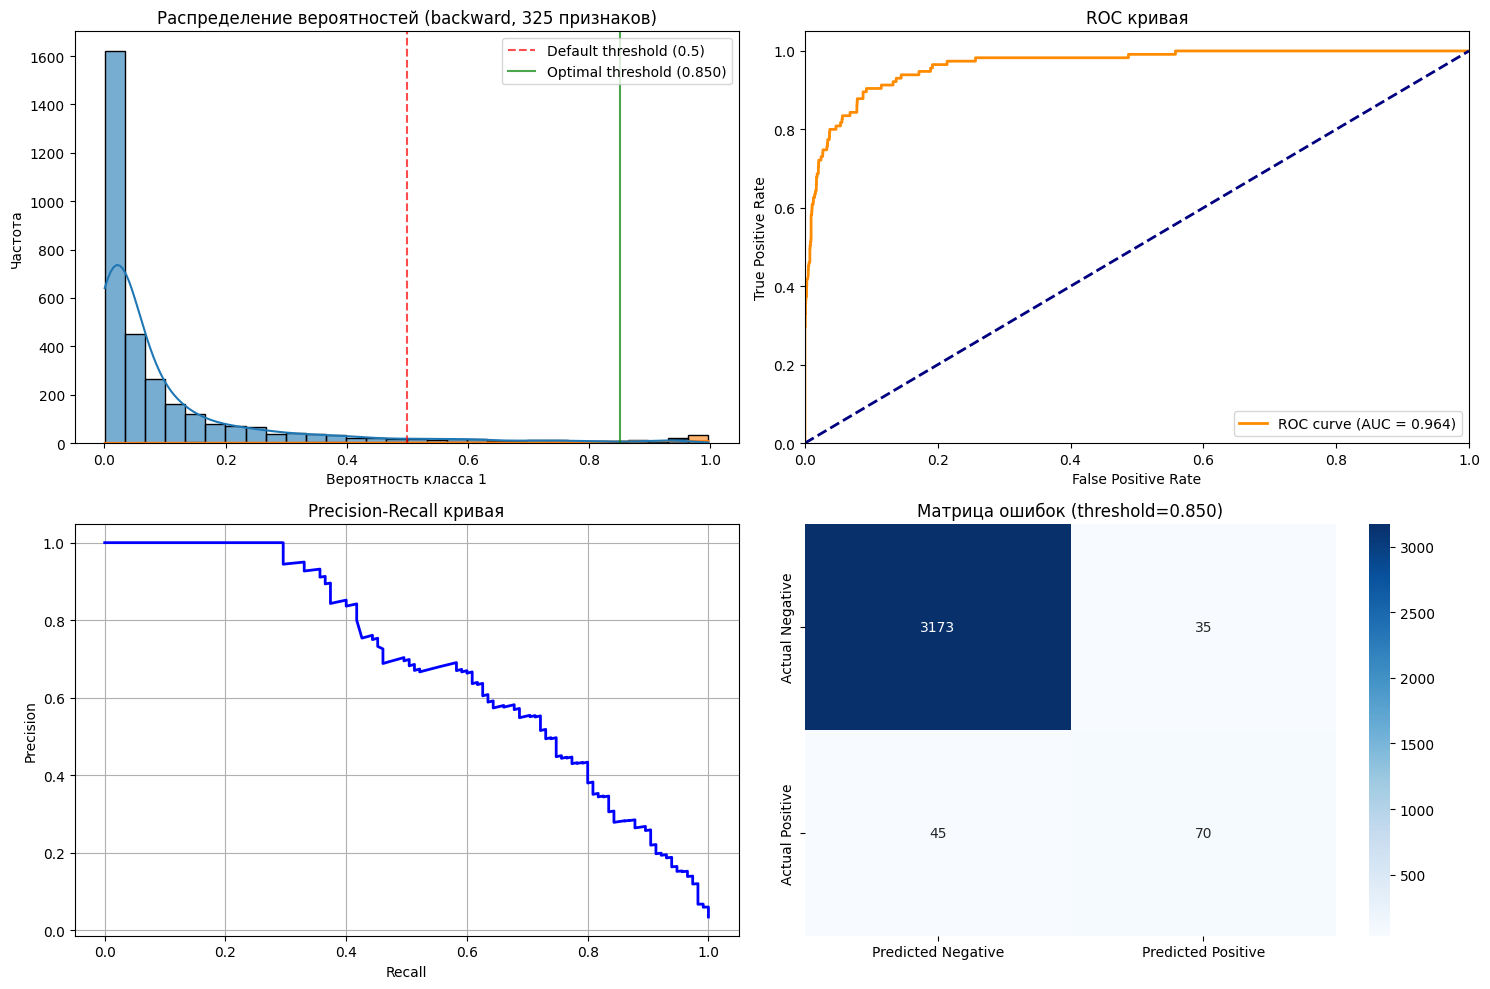

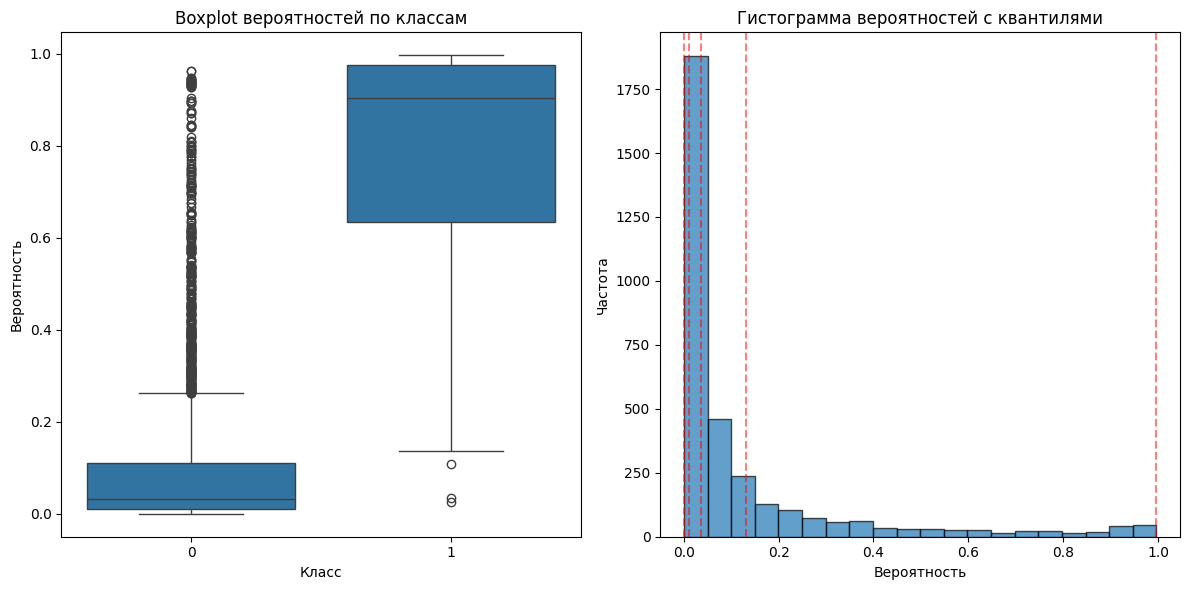

In [23]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [24]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 14
Лучшая f1: 0.4262
Признаки: ['Креатинин', 'СДЛА', 'UA_нестабильная_стенокардия', 'MKB', 'Нейтрофилы_абсолютное_значение', 'pCO2min_b', 'killip', 'Инфаркт-зависимая_артерия_Огригированная', 'Калий_K_a', 'ЧСС_b', 'Тромбоциты_a', 'Стенокардия_в_диагнозе_при_поступлении', 'Age', 'PLR_тромбоциты/лимфоциты_абс_61-239']

Важность признаков:
  Нейтрофилы_абсолютное_значение: 13.0194
  СДЛА: 11.3063
  Тромбоциты_a: 9.7625
  MKB: 9.0853
  ЧСС_b: 8.9934
  UA_нестабильная_стенокардия: 7.8544
  Калий_K_a: 7.3152
  Креатинин: 7.2835
  Инфаркт-зависимая_артерия_Огригированная: 6.9099
  killip: 5.1311
  Стенокардия_в_диагнозе_при_поступлении: 3.7657
  Age: 3.5715
  PLR_тромбоциты/лимфоциты_абс_61-239: 3.0299
  pCO2min_b: 2.9719
=== Лучшие признаки (backward) ===
Количество признаков: 325
Лучшая f1: 0.4973
Признаки: ['Age', 'Sex', 'STEMI', 'ЧКВ', 'Вид_STEMI', 'Количество_пораженных_сосудов_Syntax', 'К

In [25]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.9705 с 14 признаками
Лучший ROC AUC (Backward): 0.9637 с 325 признаками
Оптимальный порог для бинарной классификации: 0.8500


-----------------

In [26]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [27]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(xgb_model, max_features=None, metric='roc_auc')  # ограничим до 10 признакей для демонстрации

=== FORWARD SELECTION ===
Запуск Forward Selection...


  0%|          | 1/326 [00:17<1:34:22, 17.42s/it, roc_auc=0.7900, Features=1]

Step 1: Добавлен признак 'Креатинин', roc_auc: 0.7900


  1%|          | 2/326 [00:39<1:47:30, 19.91s/it, roc_auc=0.8577, Features=2]

Step 2: Добавлен признак 'СДЛА', roc_auc: 0.8577


...

Step 9: Добавлен признак 'Мин_ЧСС_3_сутки', roc_auc: 0.9561


  3%|▎         | 10/326 [04:23<2:36:09, 29.65s/it, roc_auc=0.9564, Features=10]

Step 10: Добавлен признак 'Недостаточность_аортального_клапана_степень', roc_auc: 0.9564


  3%|▎         | 10/326 [04:55<2:35:32, 29.53s/it, roc_auc=0.9564, Features=10]

Step 11: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 10


In [28]:
print("\n=== BACKWARD ELIMINATION ===")
backward_features = analyzer.backward_elimination(xgb_model, min_features=1, metric='roc_auc')


=== BACKWARD ELIMINATION ===
Запуск Backward Elimination...


  0%|          | 1/325 [05:22<29:03:31, 322.88s/it, roc_auc=0.9623, Features=325]

Step 1: Удален признак 'Нейтрофилы_относительное_значение', roc_auc: 0.9623


  1%|          | 2/325 [10:42<28:48:55, 321.16s/it, roc_auc=0.9651, Features=324]

Step 2: Удален признак 'P', roc_auc: 0.9651


...

Step 6: Удален признак 'pCO2min_a', roc_auc: 0.9655


  2%|▏         | 7/325 [36:34<27:27:26, 310.84s/it, roc_auc=0.9655, Features=319]

Step 7: Удален признак 'pCO2max', roc_auc: 0.9655


  2%|▏         | 7/325 [41:39<31:32:38, 357.10s/it, roc_auc=0.9655, Features=319]

Step 8: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 319



=== СРАВНЕНИЕ МЕТОДОВ ===


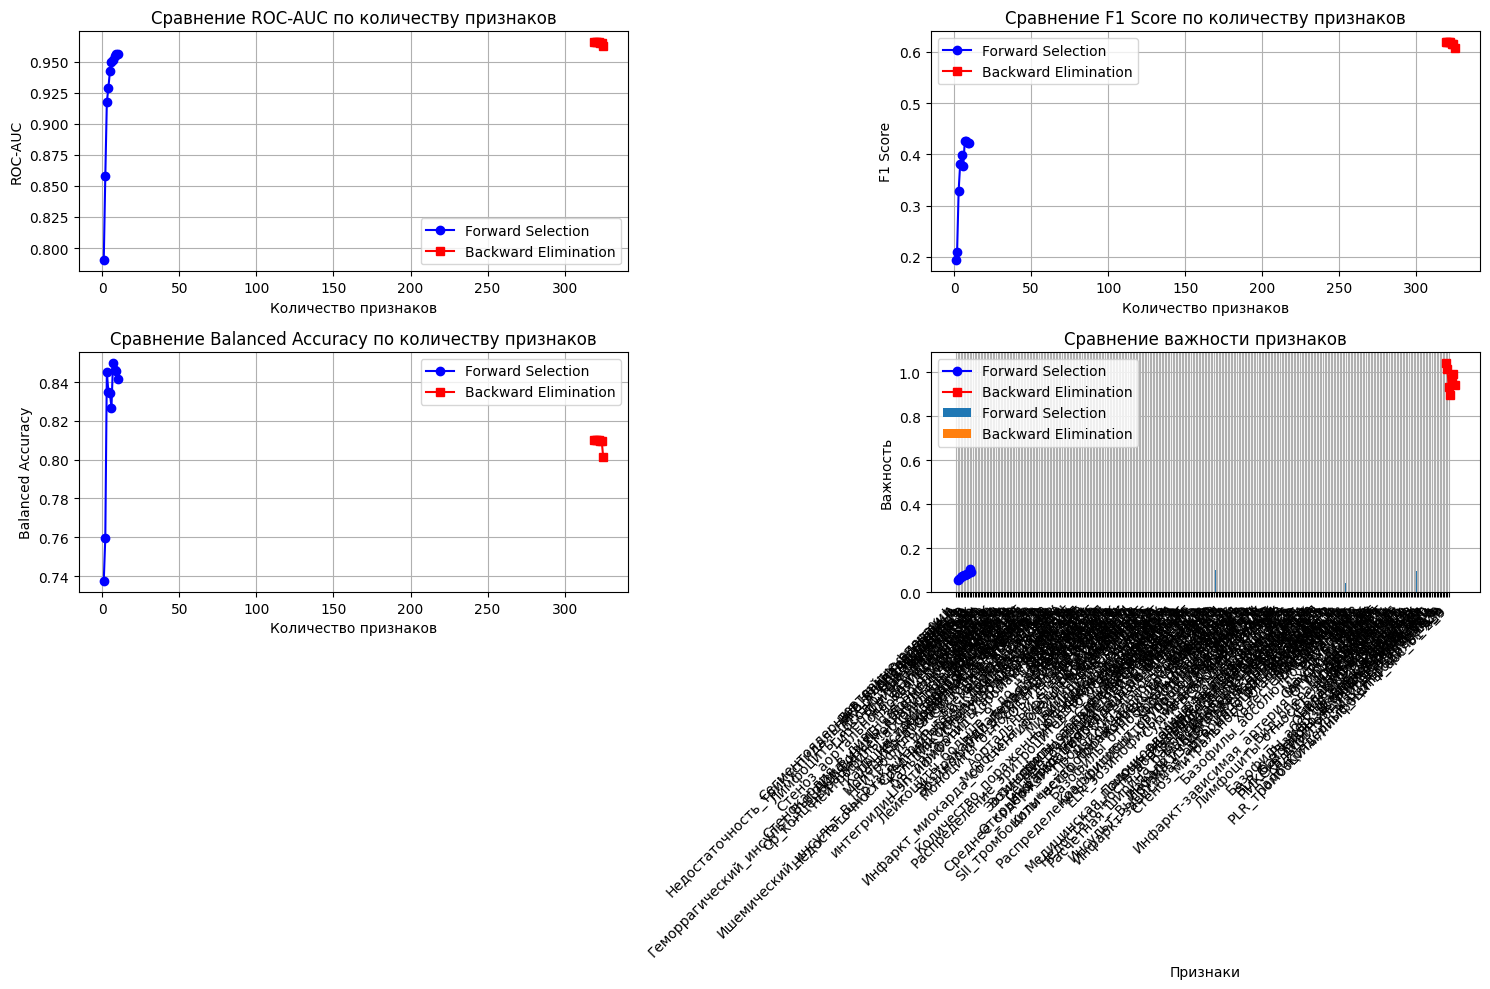

In [29]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [30]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 10 признаков) ===
По Balanced Accuracy score: 0.8200 (F1=0.5434)
По Youden's J: 0.2368


In [31]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 319 признаков) ===
По Balanced Accuracy score: 0.6500 (F1=0.6355)
По Youden's J: 0.0394



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


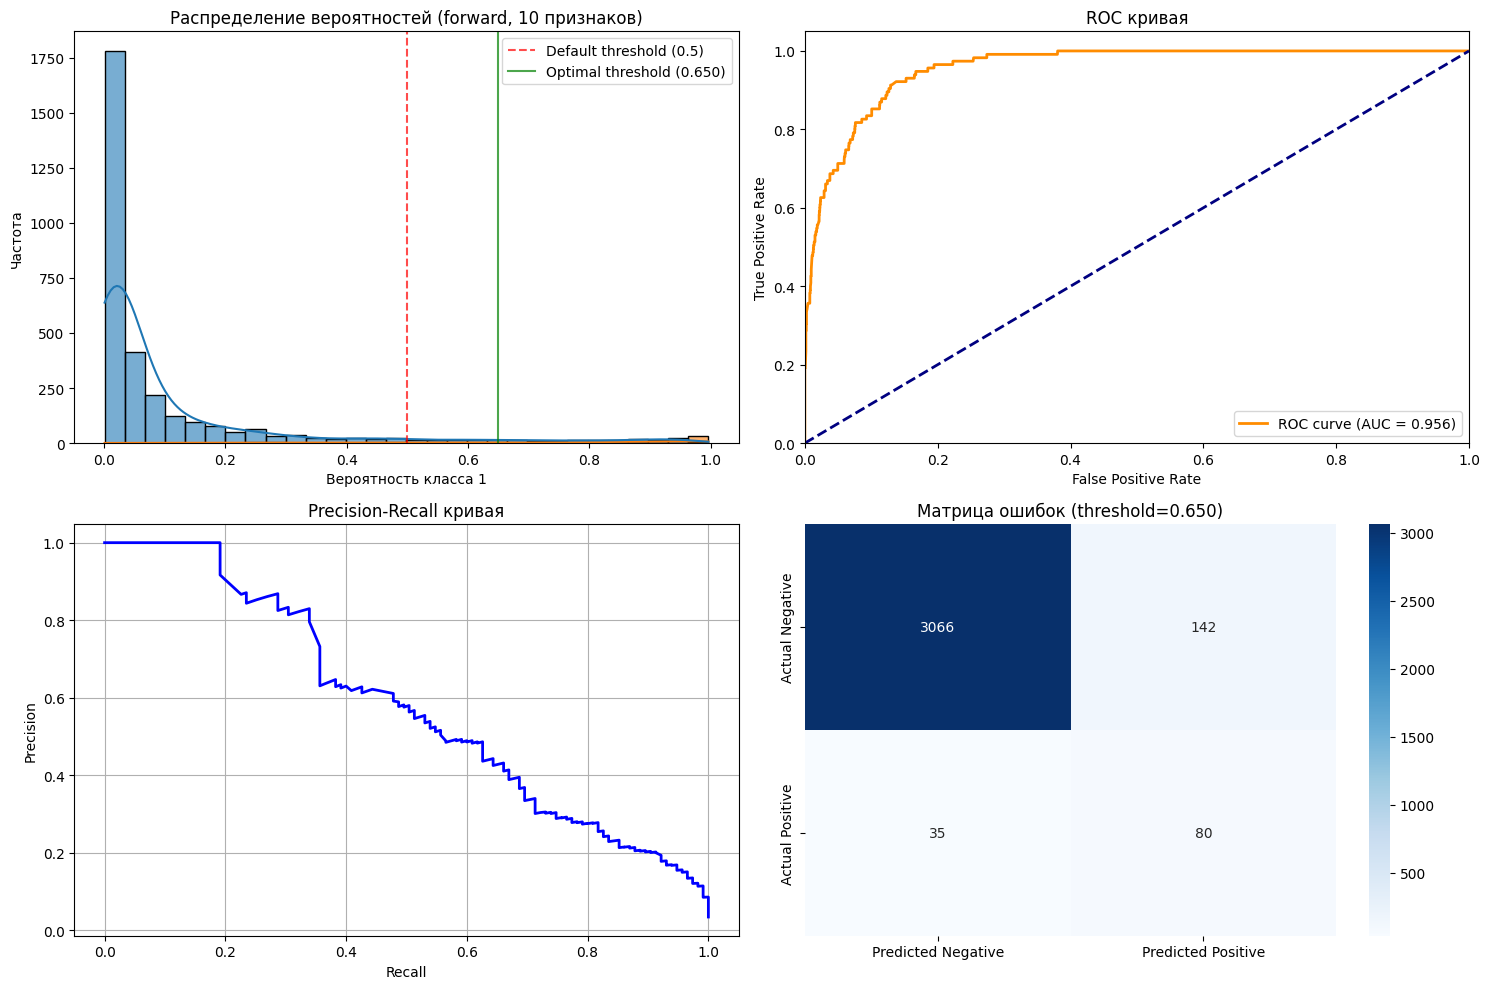

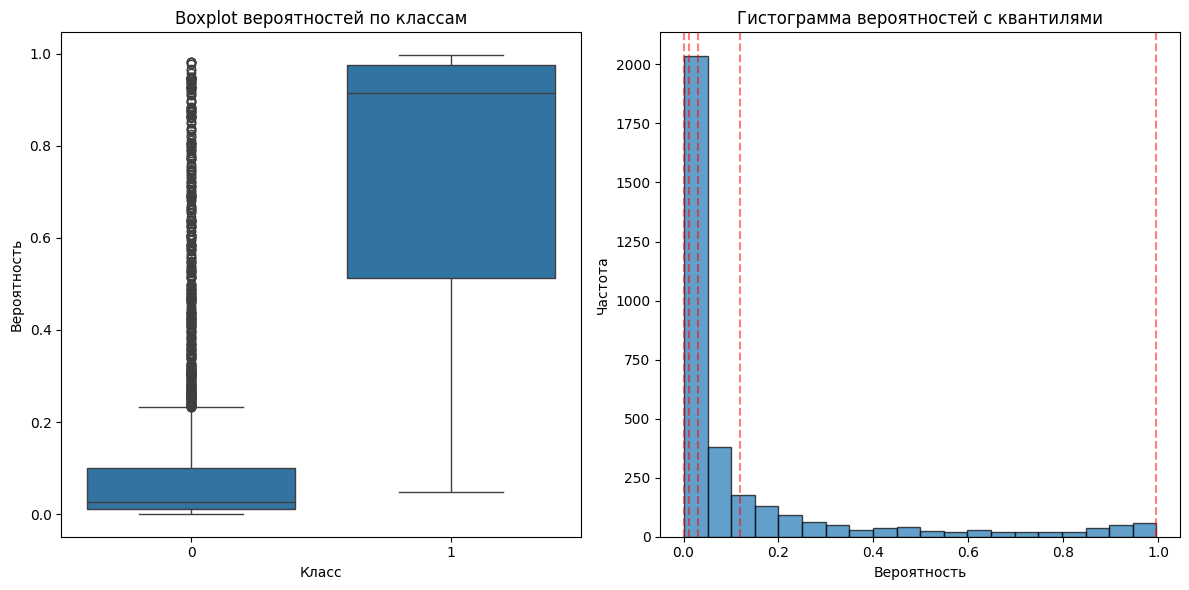

In [32]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


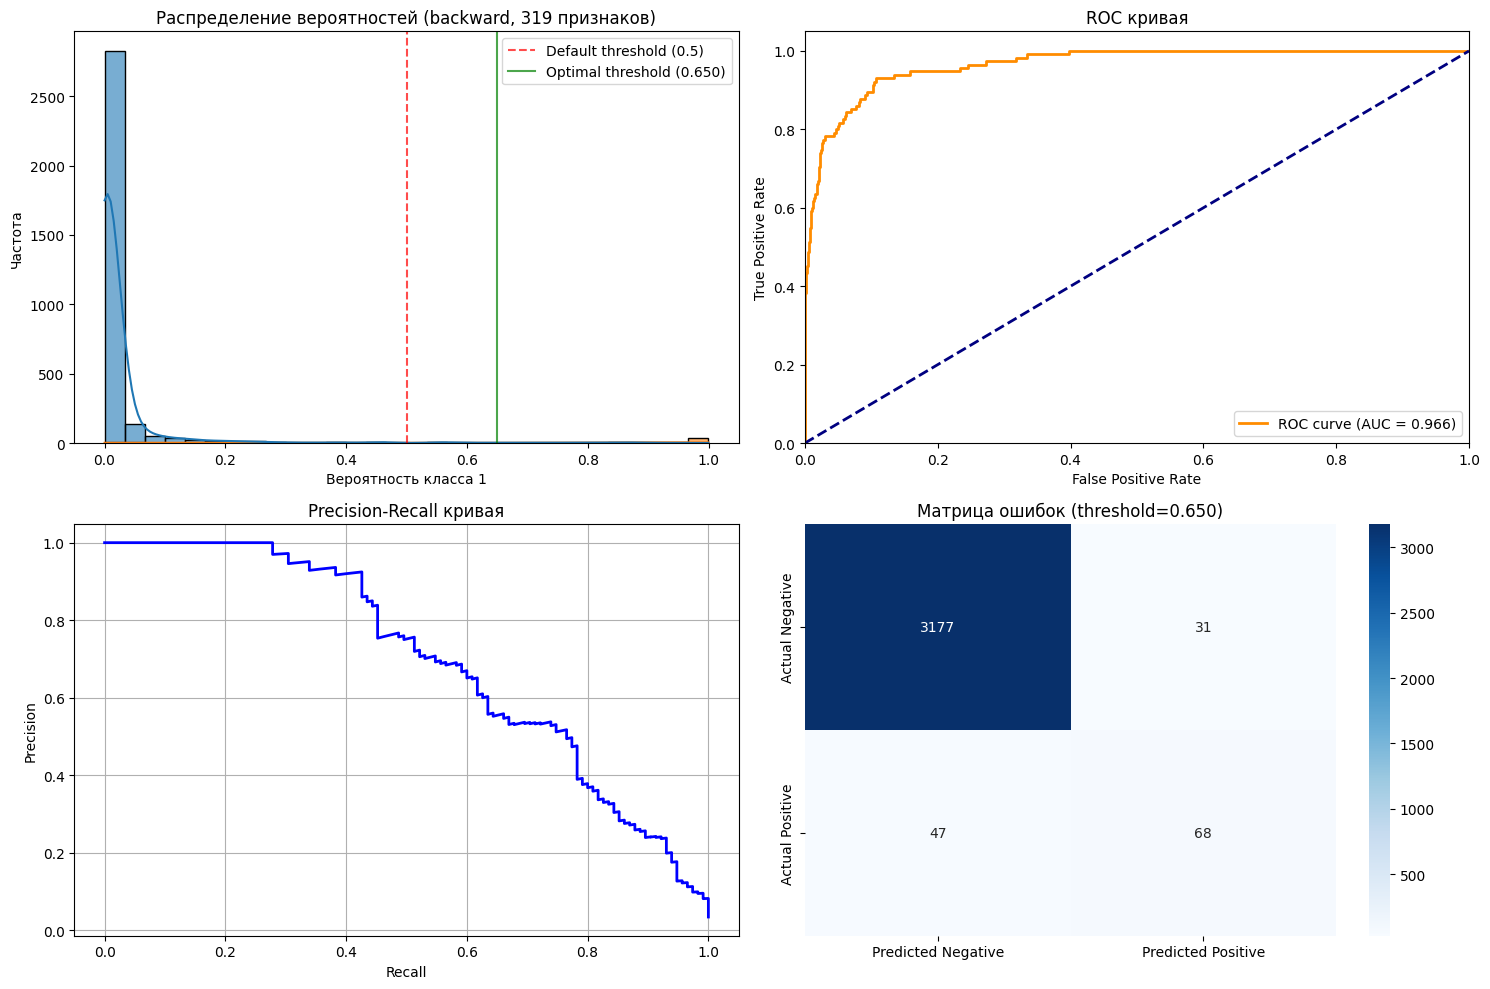

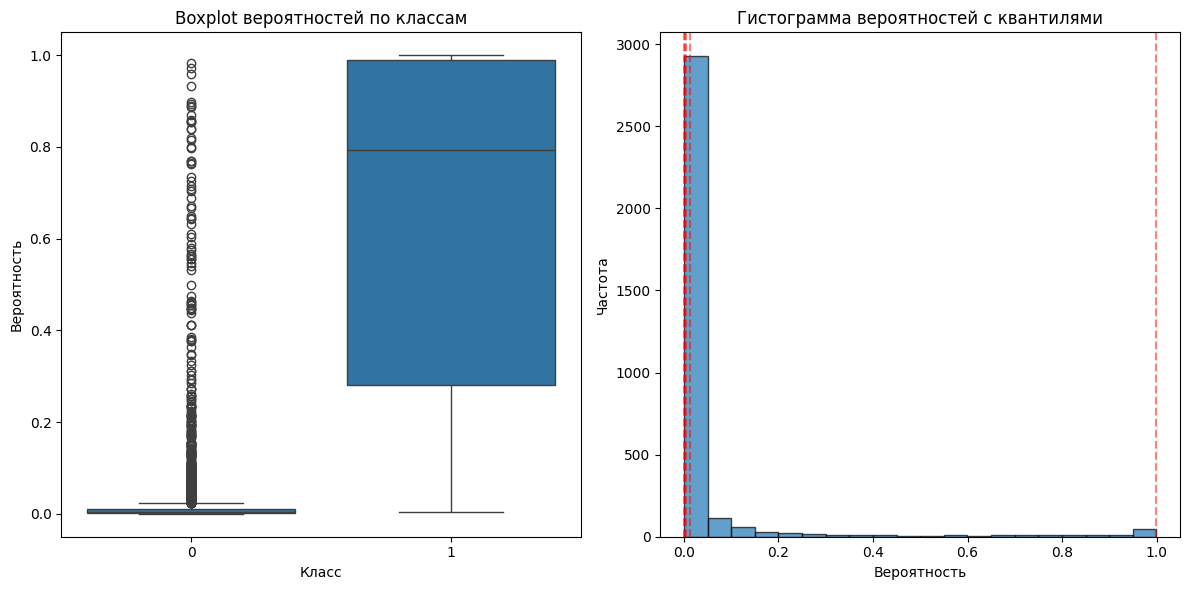

In [33]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [34]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 8
Лучшая f1: 0.4265
Признаки: ['Креатинин', 'СДЛА', 'UA_нестабильная_стенокардия', 'Нейтрофилы_абсолютное_значение', 'killip', 'pCO2max', 'повторные_операции', 'Стенокардия_в_диагнозе_при_поступлении']

Важность признаков:
  UA_нестабильная_стенокардия: 0.3594
  Нейтрофилы_абсолютное_значение: 0.1678
  killip: 0.1217
  СДЛА: 0.0980
  Креатинин: 0.0956
  Стенокардия_в_диагнозе_при_поступлении: 0.0665
  повторные_операции: 0.0485
  pCO2max: 0.0424
=== Лучшие признаки (backward) ===
Количество признаков: 322
Лучшая f1: 0.6186
Признаки: ['Age', 'Sex', 'STEMI', 'ЧКВ', 'Вид_STEMI', 'Количество_пораженных_сосудов_Syntax', 'Количество_пораженных_сосудов_Значимость', 'Инфаркт_миокарда_в_анамнезе_lt_3', 'Инфаркт_миокарда_в_анамнезе_gt_3', 'Инфаркт_миокарда_со_стентированием_в_анамнезе', 'ОНМК_иш_в_анамнезе', 'ОНМК_гем_в_анамнезе', 'Стентирование_в_анамнезе', 'Тромболизис', 'Форма_ФП', 'Калий', 'Ди

In [35]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.9542 с 8 признаками
Лучший ROC AUC (Backward): 0.9655 с 322 признаками
Оптимальный порог для бинарной классификации: 0.6500


In [36]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [37]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(lgb_model, max_features=None, metric='roc_auc')  # ограничим до 10 признакей для демонстрации

=== FORWARD SELECTION ===
Запуск Forward Selection...


  0%|          | 1/326 [00:15<1:22:27, 15.22s/it, roc_auc=0.7920, Features=1]

Step 1: Добавлен признак 'САД_a', roc_auc: 0.7920


  1%|          | 2/326 [00:34<1:35:48, 17.74s/it, roc_auc=0.8789, Features=2]

Step 2: Добавлен признак 'СДЛА', roc_auc: 0.8789


...

Step 12: Добавлен признак 'Лимфоциты_%_b', roc_auc: 0.9705


  4%|▍         | 13/326 [05:40<2:33:09, 29.36s/it, roc_auc=0.9705, Features=13]

Step 13: Добавлен признак 'Плохая_мобильность', roc_auc: 0.9705


  4%|▍         | 13/326 [06:10<2:28:40, 28.50s/it, roc_auc=0.9705, Features=13]

Step 14: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 13


In [38]:
print("=== BACKWARD SELECTION ===")
forward_features = analyzer.backward_elimination(lgb_model, min_features=1, metric='roc_auc')  # ограничим до 10 признакей для демонстрации

=== BACKWARD SELECTION ===
Запуск Backward Elimination...


  0%|          | 1/325 [02:52<15:33:12, 172.82s/it, roc_auc=0.9698, Features=325]

Step 1: Удален признак 'Нейтрофилы_относительное_значение', roc_auc: 0.9698


  1%|          | 2/325 [05:42<15:21:02, 171.09s/it, roc_auc=0.9716, Features=324]

Step 2: Удален признак 'PCO2VenMax_b', roc_auc: 0.9716


  1%|          | 3/325 [08:33<15:16:53, 170.85s/it, roc_auc=0.9716, Features=323]

Step 3: Удален признак 'Инфаркт_миокарда_со_стентированием_в_анамнезе', roc_auc: 0.9716


  1%|          | 3/325 [11:23<20:21:50, 227.67s/it, roc_auc=0.9716, Features=323]

Step 4: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 323



=== СРАВНЕНИЕ МЕТОДОВ ===


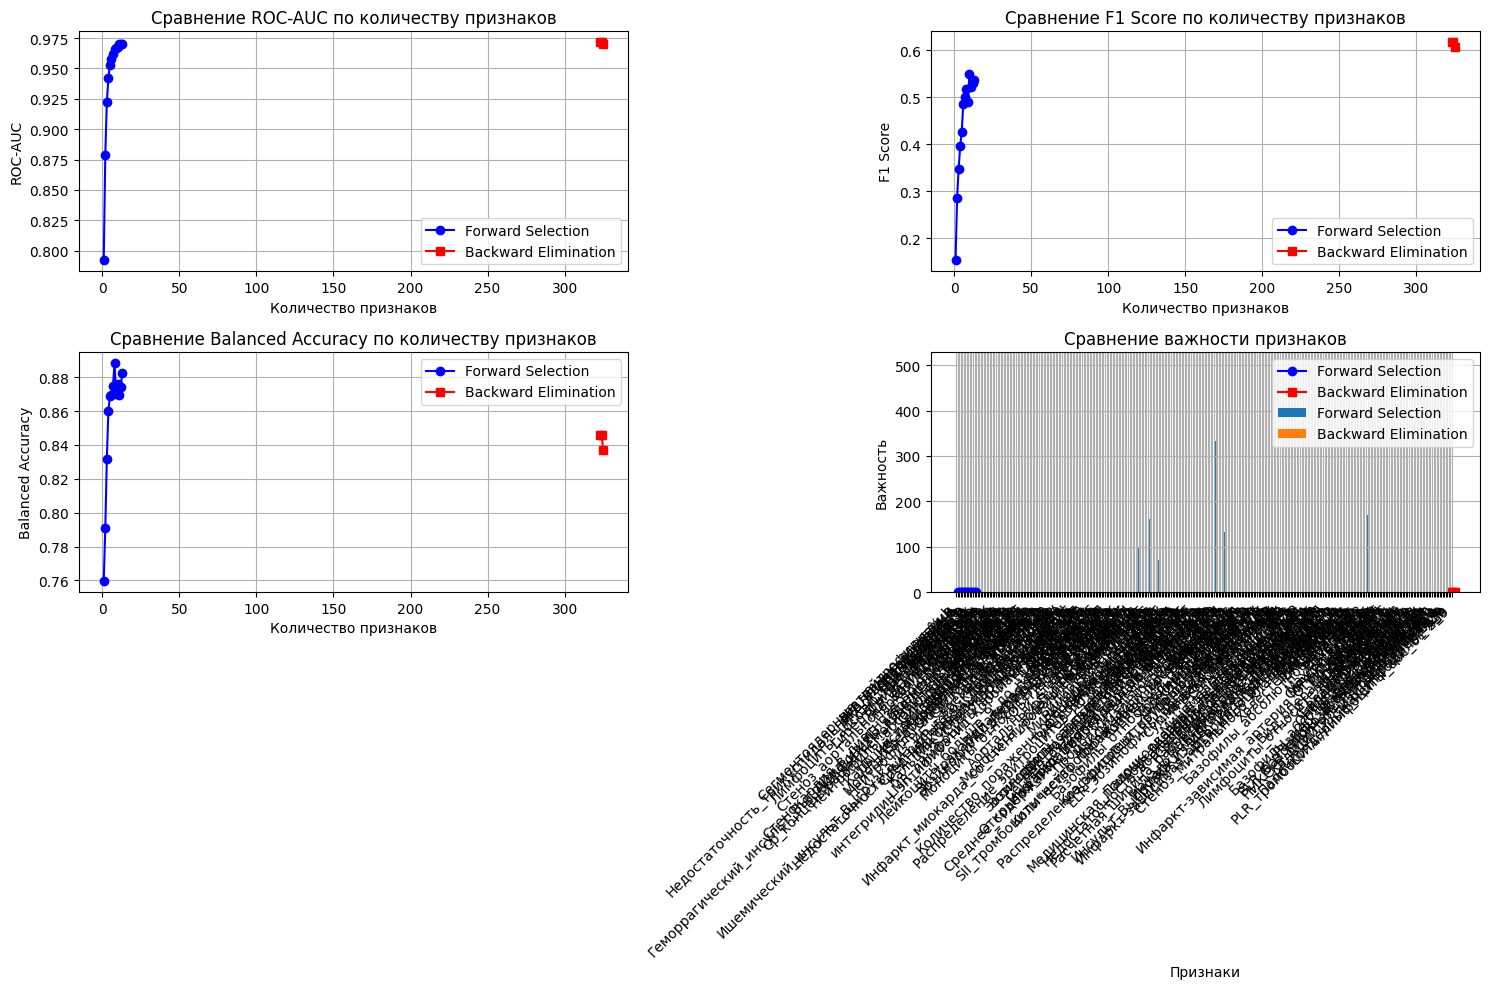

In [39]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [40]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 13 признаков) ===
По Balanced Accuracy score: 0.6700 (F1=0.5985)
По Youden's J: 0.2139


In [41]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 323 признаков) ===
По Balanced Accuracy score: 0.7900 (F1=0.6825)
По Youden's J: 0.0531



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


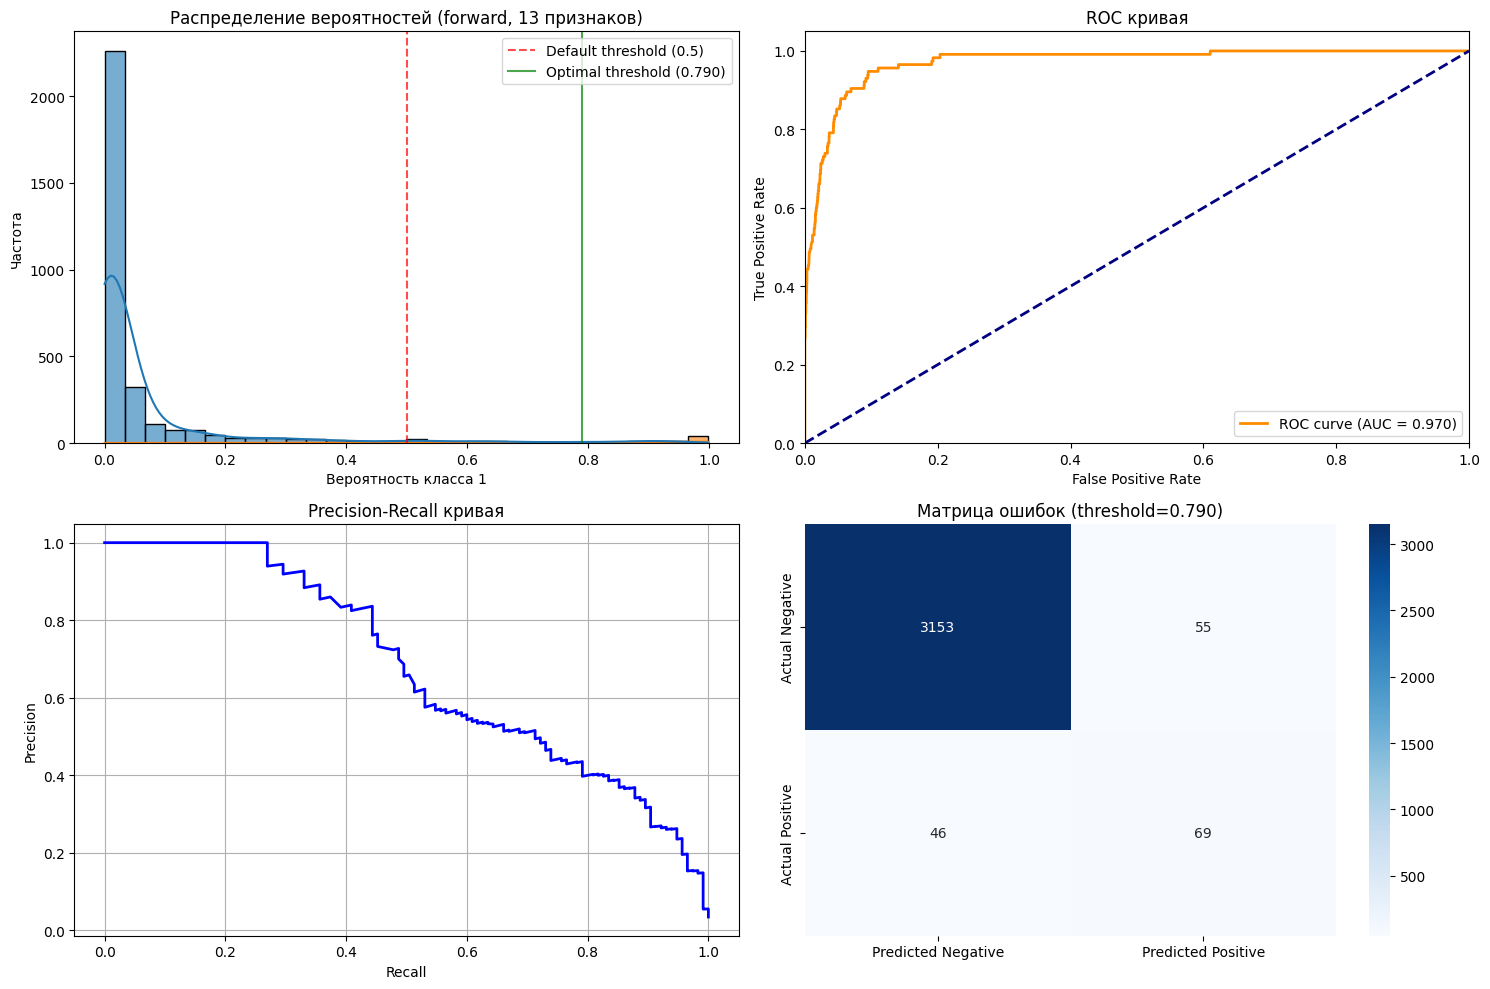

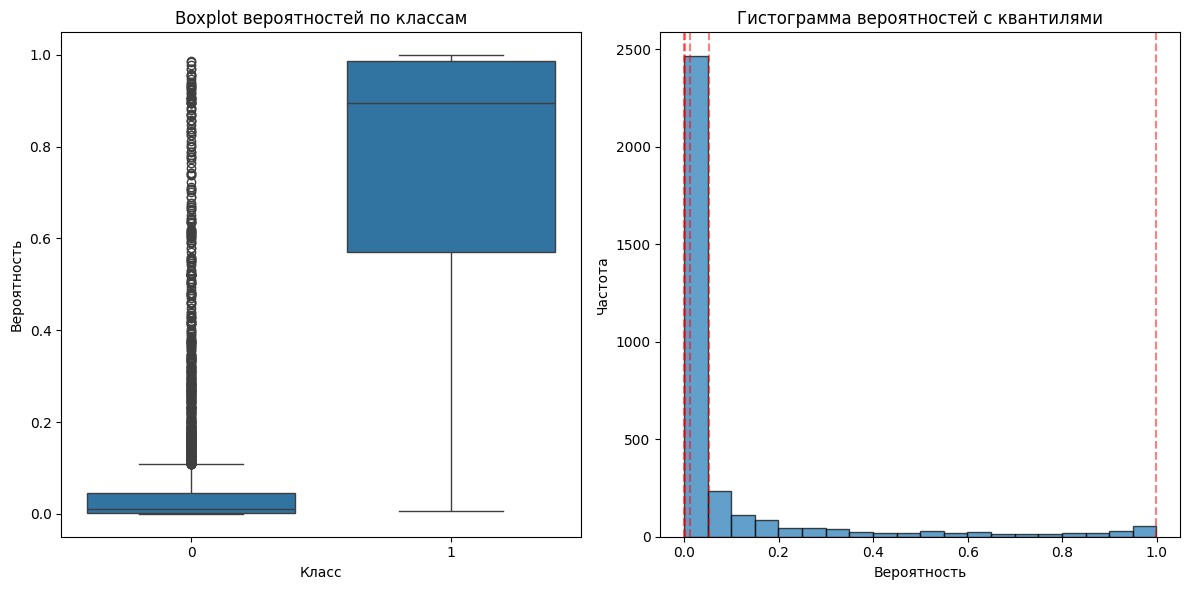

In [42]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


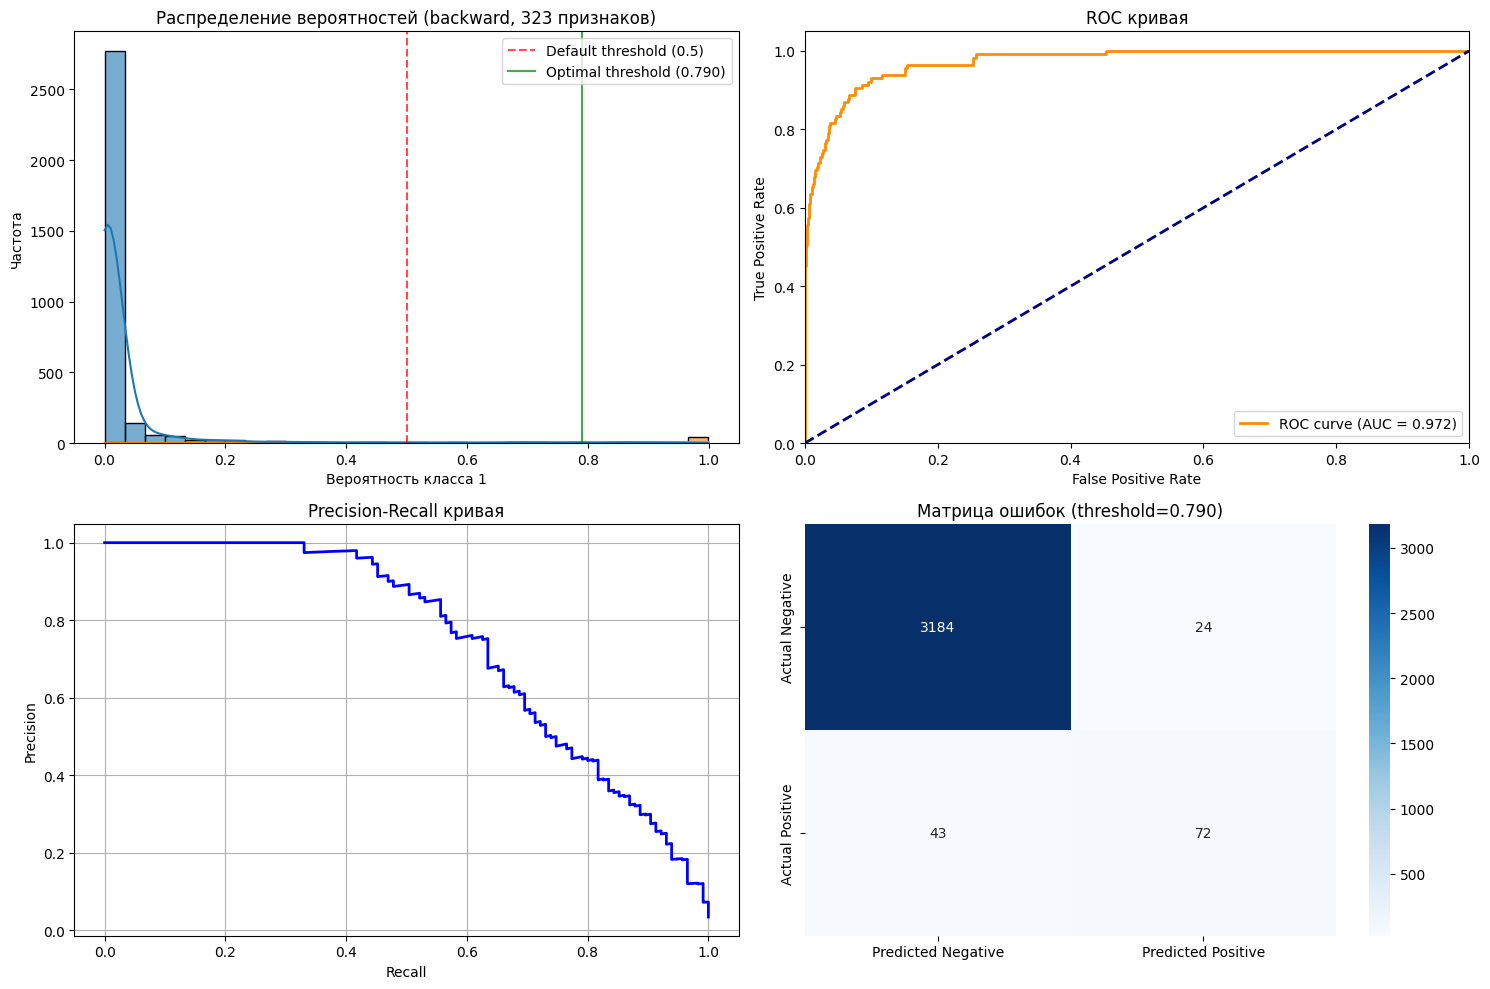

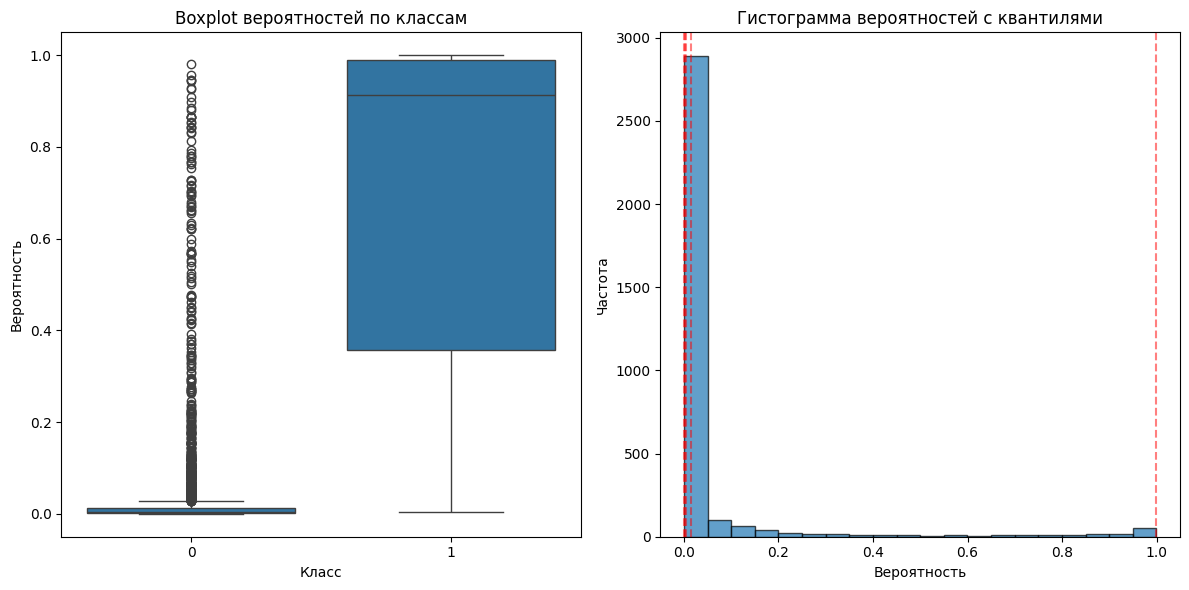

In [43]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [44]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 10
Лучшая f1: 0.5482
Признаки: ['САД_a', 'СДЛА', 'MKB', 'Нейтрофилы_абсолютное_значение', 'Вид_STEMI', 'Глюкоза_a', 'LactVenMax_a', 'Минимальное_АД_1_сут', 'HCO3VenMin_a', 'killip']

Важность признаков:
  Нейтрофилы_абсолютное_значение: 504.0000
  Глюкоза_a: 335.0000
  СДЛА: 334.0000
  САД_a: 196.0000
  MKB: 180.0000
  killip: 170.0000
  LactVenMax_a: 161.0000
  Вид_STEMI: 133.0000
  HCO3VenMin_a: 97.0000
  Минимальное_АД_1_сут: 70.0000
=== Лучшие признаки (backward) ===
Количество признаков: 324
Лучшая f1: 0.6165
Признаки: ['Age', 'Sex', 'STEMI', 'ЧКВ', 'Вид_STEMI', 'Количество_пораженных_сосудов_Syntax', 'Количество_пораженных_сосудов_Значимость', 'Инфаркт_миокарда_в_анамнезе_lt_3', 'Инфаркт_миокарда_в_анамнезе_gt_3', 'Инфаркт_миокарда_со_стентированием_в_анамнезе', 'ОНМК_иш_в_анамнезе', 'ОНМК_гем_в_анамнезе', 'Стентирование_в_анамнезе', 'Тромболизис', 'Форма_ФП', 'Калий', 'Дилатация_п

In [45]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.9681 с 10 признаками
Лучший ROC AUC (Backward): 0.9716 с 324 признаками
Оптимальный порог для бинарной классификации: 0.7900
